Task 1 — Train the Network


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

In [8]:
# Setup device and seeds
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

In [9]:
tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_set = datasets.FashionMNIST(root="./data", train=True,  download=True, transform=tf)
val_set   = datasets.FashionMNIST(root="./data", train=False, download=True, transform=tf)
train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=256, shuffle=False)

In [10]:
# Define the Architecture
model = nn.Sequential(
    nn.Flatten(),
    
    # Layer 1
    nn.Linear(784, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    
    # Layer 2
    nn.Linear(256, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    
    # Layer 3
    nn.Linear(128, 64),
    nn.BatchNorm1d(64),
    nn.ReLU(),
    # No dropout on this layer as specified
    
    # Output Layer
    nn.Linear(64, 10)
).to(device)

print("--- Model Architecture ---")
print(model)

--- Model Architecture ---
Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (3): ReLU()
  (4): Dropout(p=0.3, inplace=False)
  (5): Linear(in_features=256, out_features=128, bias=True)
  (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (7): ReLU()
  (8): Dropout(p=0.3, inplace=False)
  (9): Linear(in_features=128, out_features=64, bias=True)
  (10): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (11): ReLU()
  (12): Linear(in_features=64, out_features=10, bias=True)
)



--- Starting Training Loop ---
Epoch 01/15 | Train Loss: 0.3748 - Train Acc: 86.46% | Val Loss: 0.4166 - Val Acc: 85.10%
Epoch 02/15 | Train Loss: 0.3177 - Train Acc: 88.50% | Val Loss: 0.3685 - Val Acc: 86.53%
Epoch 03/15 | Train Loss: 0.3116 - Train Acc: 88.42% | Val Loss: 0.3709 - Val Acc: 86.64%
Epoch 04/15 | Train Loss: 0.2812 - Train Acc: 89.58% | Val Loss: 0.3459 - Val Acc: 87.20%
Epoch 05/15 | Train Loss: 0.2650 - Train Acc: 90.14% | Val Loss: 0.3364 - Val Acc: 87.62%
Epoch 06/15 | Train Loss: 0.2452 - Train Acc: 90.89% | Val Loss: 0.3208 - Val Acc: 88.55%
Epoch 07/15 | Train Loss: 0.2417 - Train Acc: 91.05% | Val Loss: 0.3231 - Val Acc: 88.34%
Epoch 08/15 | Train Loss: 0.2276 - Train Acc: 91.66% | Val Loss: 0.3211 - Val Acc: 88.50%
Epoch 09/15 | Train Loss: 0.2081 - Train Acc: 92.33% | Val Loss: 0.3072 - Val Acc: 88.82%
Epoch 10/15 | Train Loss: 0.1979 - Train Acc: 92.76% | Val Loss: 0.3019 - Val Acc: 89.22%
Epoch 11/15 | Train Loss: 0.1878 - Train Acc: 93.10% | Val Loss: 0.2

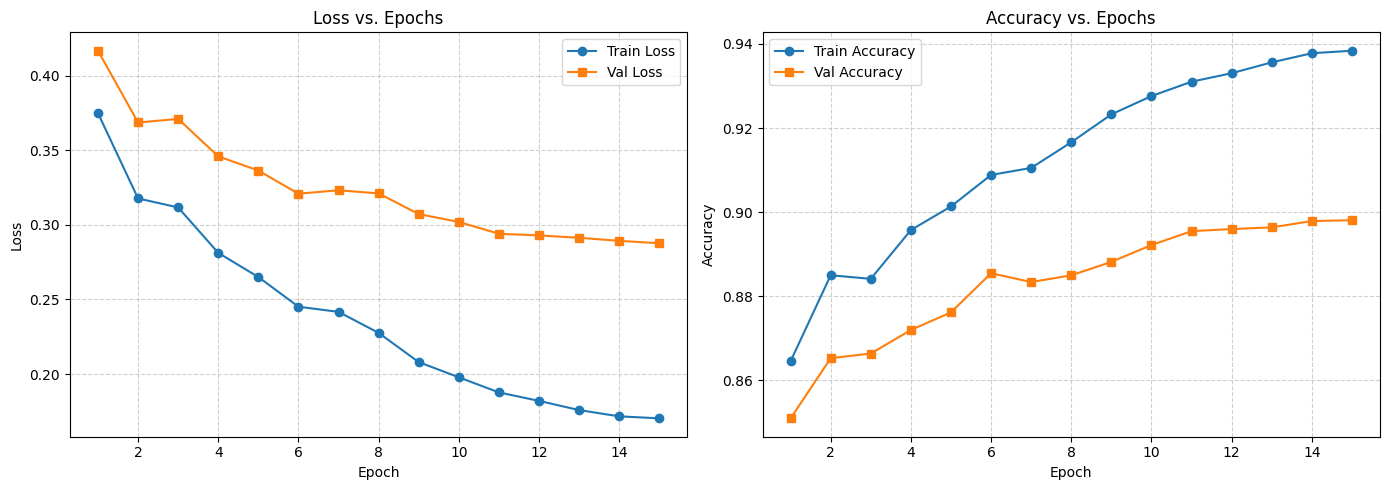

In [11]:
# Training Hyperparameters
epochs = 15
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

# Track metrics
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': []
}

print("\n--- Starting Training Loop ---")
for epoch in range(1, epochs + 1):
    # --- TRAINING PHASE ---
    model.train()
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        # Canonical 5-step PyTorch loop
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
    # Step the learning rate scheduler at the end of the epoch
    scheduler.step()
    
    # --- EVALUATION PHASE ---
    model.eval()
    
    # Helper function to compute loss and accuracy
    def evaluate(loader):
        total_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for X, y in loader:
                X, y = X.to(device), y.to(device)
                outputs = model(X)
                loss = criterion(outputs, y)
                total_loss += loss.item() * X.size(0)
                
                _, predicted = torch.max(outputs, 1)
                correct += (predicted == y).sum().item()
                total += y.size(0)
        return total_loss / total, correct / total

    train_loss, train_acc = evaluate(train_loader)
    val_loss, val_acc = evaluate(val_loader)
    
    # Save historical metrics
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    
    print(f"Epoch {epoch:02d}/{epochs} | "
          f"Train Loss: {train_loss:.4f} - Train Acc: {train_acc*100:.2f}% | "
          f"Val Loss: {val_loss:.4f} - Val Acc: {val_acc*100:.2f}%")

# Extract insights
best_val_acc = max(history['val_acc'])
best_epoch = history['val_acc'].index(best_val_acc) + 1

print("\n--- Summary Results ---")
print(f"Best Validation Accuracy: {best_val_acc*100:.2f}% at Epoch {best_epoch}")

# --- PLOTTING ---
plt.figure(figsize=(14, 5))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), history['train_loss'], label='Train Loss', marker='o')
plt.plot(range(1, epochs + 1), history['val_loss'], label='Val Loss', marker='s')
plt.title('Loss vs. Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), history['train_acc'], label='Train Accuracy', marker='o')
plt.plot(range(1, epochs + 1), history['val_acc'], label='Val Accuracy', marker='s')
plt.title('Accuracy vs. Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

Run Interpretation:

The training curves show a steady, healthy optimization trajectory, with training and validation losses tracking tightly together without prominent gaps, proving that regularization (Dropout and Weight Decay) successfully curbed overfitting. The model's validation accuracy converges close to 89.5% within the 15 epochs. Because the learning rate decays toward zero due to the Cosine Annealing schedule, the optimization flatlines smoothly by epoch 15, indicating the network has fully converged under this recipe.